# Primer Parcial de Inteligencia Artificial
## Predicción de aprobación en Señales y Sistemas

### Pregunta de investigación
**¿Es posible predecir si un estudiante aprobará Señales y Sistemas utilizando su nota del primer parcial y características de su rendimiento académico previo?**

### Cómo planteo el problema
trabajo con un problema de **clasificación binaria**. Mi variable objetivo vale:

- `1` si el estudiante aprobó.
- `0` si no aprobó.

No se construye el target directamente desde la columna `Aprobado`. Se reconstruye desde `Nota.Final` usando el criterio académico que estoy utilizando:

- `1F-2` → aprobó.
- `2F-1` → no aprobó.
- `1F-1,2F-4` → aprobó porque existe una nota final 4.
- La nota mínima aprobatoria es 2 y la máxima es 5.

### Idea principal de mi feature engineering
No quiero depender únicamente de `Primer.Par`. También construyo información del semestre anterior:

- cantidad de materias cursadas;
- cantidad de materias aprobadas;
- tasa de aprobación;
- **promedio de Firma**;
- promedio del primer parcial de las materias previas;
- promedio del segundo parcial de las materias previas;
- indicador de malla nueva/vieja.

De esta forma intento representar mejor el rendimiento académico previo.

**Importante:** `ALUMNO_ID` me sirve para identificar y agrupar registros, pero **no lo uso como predictor**. Un identificador no representa desempeño académico y no permitiría generalizar a estudiantes nuevos.

## 0. Librerías

In [1]:
from pathlib import Path
import hashlib
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

RANDOM_STATE = 42

# 1. Carga de los cuatro ciclos

primero se sube los cuatro archivos Excel al panel **Archivos**.

El código busca los `.xlsx` dentro de `/content`.  
También incluye una ruta alternativa para poder ejecutar el notebook fuera de Colab.

In [2]:
rutas_posibles = [
    Path("/content"),
    Path("/mnt/data/ia_work/BaseDatos1P"),
    Path("/mnt/data/ia_data_extract/BaseDatos1P"),
    Path("BaseDatos1P")
]

DATA_DIR = next(
    (
        ruta for ruta in rutas_posibles
        if ruta.exists()
        and len(list(ruta.glob("*.xlsx"))) >= 4
    ),
    None
)

if DATA_DIR is None:
    raise FileNotFoundError(
        "No se encontraron los cuatro Excel. "
        "En Colab, súbelos al panel Archivos y vuelve a ejecutar."
    )

archivos = sorted([
    p for p in DATA_DIR.glob("*.xlsx")
    if "rendimiento" in p.name.lower()
])

print("Archivos encontrados:", len(archivos))
for archivo in archivos:
    print(" -", archivo.name)

if len(archivos) != 4:
    raise ValueError(
        f"Se esperaban 4 archivos de rendimiento y se encontraron {len(archivos)}."
    )

dfs = []

for archivo in archivos:
    temp = pd.read_excel(archivo)
    temp["archivo_origen"] = archivo.name
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True, sort=False)

print("\nDimensiones de la base completa:", df.shape)

print("\nRegistros por año y semestre:")
print(df.groupby(["Anho", "Semestre"]).size())

Archivos encontrados: 4
 - rendimiento_aдo_2024_ciclo_1_anon.xlsx
 - rendimiento_aдo_2024_ciclo_2_anon.xlsx
 - rendimiento_aдo_2025_ciclo_1_anon.xlsx
 - rendimiento_aдo_2025_ciclo_2_anon.xlsx

Dimensiones de la base completa: (87147, 31)

Registros por año y semestre:
Anho  Semestre
2024  1           22852
      2           24468
2025  1           19407
      2           20420
dtype: int64


# 2. Limpieza y normalización

Los Excel contienen algunos espacios al final de los códigos de plan.  
Además, se normalizan tildes y la `ñ` para evitar errores al filtrar nombres.

In [3]:
columnas_texto = [
    "ALUMNO_ID",
    "Cod.Asign",
    "Asignatura",
    "Cod.Car.Sec",
    "Aprobado",
    "Nota.Final"
]

for col in columnas_texto:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()


def normalizar_texto(valor):
    if pd.isna(valor):
        return ""

    texto = str(valor).strip().upper()

    texto = unicodedata.normalize("NFKD", texto)
    texto = texto.encode("ascii", "ignore").decode("ascii")
    texto = re.sub(r"\s+", " ", texto)

    return texto


df["Asignatura_norm"] = df["Asignatura"].map(normalizar_texto)

df["Plan_norm"] = (
    df["Cod.Car.Sec"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace("_", "-", regex=False)
)

print("Normalización completada.")

Normalización completada.


# 3. Reconstrucción del resultado desde `Nota.Final`

Una cadena como:

`1F-1,2F-4`

contiene dos calificaciones finales: 1 y 4.

Para decidir aprobación se revisan **todas** las notas registradas, porque en la base el orden textual no siempre coincide con el número de final.  
Si existe al menos una nota `>= 2`, el alumno aprobó.

También se construye `NotaFinal_num` como la mayor nota final registrada, útil para análisis descriptivo.

In [4]:
def extraer_notas_finales(valor):
    if pd.isna(valor):
        return []

    coincidencias = re.findall(
        r"(\d+)\s*F\s*-\s*([1-5])",
        str(valor).upper()
    )

    return [int(nota) for _, nota in coincidencias]


def nota_final_numerica(valor):
    notas = extraer_notas_finales(valor)

    if len(notas) == 0:
        return np.nan

    return float(max(notas))


def aprobado_desde_nota_final(valor):
    notas = extraer_notas_finales(valor)

    return int(
        any(nota >= 2 for nota in notas)
    )


df["NotaFinal_num"] = df["Nota.Final"].apply(
    nota_final_numerica
)

df["Aprobado_nf"] = df["Nota.Final"].apply(
    aprobado_desde_nota_final
)

print("Ejemplos:")
ejemplos = pd.Series([
    "2F-1",
    "1F-2",
    "1F-1,2F-4",
    "3F-2,2F-1",
    np.nan
])

tabla_ejemplo = pd.DataFrame({
    "Nota.Final": ejemplos,
    "NotaFinal_num": ejemplos.apply(nota_final_numerica),
    "Aprobado_calculado": ejemplos.apply(aprobado_desde_nota_final)
})

display(tabla_ejemplo)

Ejemplos:


,Nota.Final,NotaFinal_num,Aprobado_calculado
0,2F-1,1.000,0
1,1F-2,2.000,1
2,"1F-1,2F-4",4.000,1
3,"3F-2,2F-1",2.000,1
4,NaN,NaN,0


# 4. Filtrado de Señales y Sistemas

Planes utilizados:

- `MCT-PLS13`: malla vieja.
- `MCT-PLS23`: malla nueva.

In [5]:
mask_senales = (
    (df["Asignatura_norm"] == "SENALES Y SISTEMAS")
    &
    (df["Plan_norm"].isin([
        "MCT-PLS13",
        "MCT-PLS23"
    ]))
)

senales_raw = df.loc[mask_senales].copy()

if senales_raw.empty:
    raise ValueError(
        "No se encontraron registros de Señales y Sistemas."
    )

print("Registros encontrados:", len(senales_raw))
print("ALUMNO_ID distintos:", senales_raw["ALUMNO_ID"].nunique())

print("\nPor año y semestre:")
print(senales_raw.groupby(["Anho", "Semestre"]).size())

print("\nPor malla:")
print(senales_raw["Plan_norm"].value_counts())

Registros encontrados: 98
ALUMNO_ID distintos: 82

Por año y semestre:
Anho  Semestre
2024  2           60
2025  2           38
dtype: int64

Por malla:
Plan_norm
MCT-PLS13    72
MCT-PLS23    26
Name: count, dtype: int64


## 4.1. Verificación del criterio de aprobación

Aquí se compara:

- `Aprobado`: columna original de la base.
- `Aprobado_nf`: variable reconstruida únicamente desde `Nota.Final`.

Para **Señales y Sistemas**, ambas deberían coincidir en los datos proporcionados.

In [6]:
senales_raw["Aprobado_original_num"] = (
    senales_raw["Aprobado"]
    .astype(str)
    .str.upper()
    .str.strip()
    .map({"S": 1, "N": 0})
)

comparacion_target = pd.crosstab(
    senales_raw["Aprobado_original_num"],
    senales_raw["Aprobado_nf"],
    rownames=["Aprobado original"],
    colnames=["Aprobado desde Nota.Final"]
)

display(comparacion_target)

coincidencia = (
    senales_raw["Aprobado_original_num"]
    == senales_raw["Aprobado_nf"]
).mean() * 100

print(f"Coincidencia en Señales y Sistemas: {coincidencia:.1f}%")

Aprobado desde Nota.Final,0,1
Aprobado original,,
0,34,0
1,0,64


Coincidencia en Señales y Sistemas: 100.0%


In [7]:
# ============================================================
# FEATURE ENGINEERING PARA LOS 98 REGISTROS ORIGINALES
# ============================================================

revision_98 = senales_raw.copy().reset_index(drop=True)

# Listas para guardar las características construidas
lista_cursadas = []
lista_aprobadas = []
lista_tasa = []

lista_promedio_firma = []
lista_desvio_firma = []
lista_firma_max = []
lista_firma_min = []

lista_promedio_p1 = []
lista_promedio_p2 = []

for _, fila in revision_98.iterrows():

    alumno_id = fila["ALUMNO_ID"]
    anho = int(fila["Anho"])
    semestre = int(fila["Semestre"])

    # --------------------------------------------------------
    # Buscar el semestre inmediatamente anterior
    # --------------------------------------------------------
    anterior = df[
        (df["ALUMNO_ID"] == alumno_id)
        &
        (df["Anho"] == anho)
        &
        (df["Semestre"] == semestre - 1)
    ].copy()

    # Cada asignatura se cuenta una sola vez.
    anterior = anterior.drop_duplicates("Cod.Asign")

    # ========================================================
    # 1. CANTIDAD DE MATERIAS Y TASA DE APROBACIÓN
    # ========================================================

    materias_cursadas = len(anterior)

    materias_aprobadas = int(
        anterior["Aprobado_nf"].sum()
    )

    tasa_aprobacion = (
        materias_aprobadas / materias_cursadas
        if materias_cursadas > 0
        else np.nan
    )

    # ========================================================
    # 2. FIRMA DEL SEMESTRE ANTERIOR
    # ========================================================

    firmas = pd.to_numeric(
        anterior["Firma"],
        errors="coerce"
    )

    # Un valor negativo se trata como faltante porque queda
    # fuera de la escala académica esperada.
    firmas = firmas.where(firmas >= 0, np.nan)

    promedio_firma = firmas.mean()
    desvio_firma = firmas.std(ddof=0)
    firma_max = firmas.max()
    firma_min = firmas.min()

    # ========================================================
    # 3. RENDIMIENTO EN PARCIALES DEL SEMESTRE ANTERIOR
    # ========================================================

    p1_anterior = pd.to_numeric(
        anterior["Primer.Par"],
        errors="coerce"
    )

    p2_anterior = pd.to_numeric(
        anterior["Segundo.Par"],
        errors="coerce"
    )

    promedio_p1 = p1_anterior.mean()
    promedio_p2 = p2_anterior.mean()

    # ========================================================
    # GUARDAR RESULTADOS
    # ========================================================

    lista_cursadas.append(materias_cursadas)
    lista_aprobadas.append(materias_aprobadas)
    lista_tasa.append(tasa_aprobacion)

    lista_promedio_firma.append(promedio_firma)
    lista_desvio_firma.append(desvio_firma)
    lista_firma_max.append(firma_max)
    lista_firma_min.append(firma_min)

    lista_promedio_p1.append(promedio_p1)
    lista_promedio_p2.append(promedio_p2)


# ============================================================
# AGREGAR LAS NUEVAS FEATURES
# ============================================================

revision_98["materias_cursadas_anterior"] = lista_cursadas
revision_98["materias_aprobadas_anterior"] = lista_aprobadas
revision_98["tasa_aprobacion_anterior"] = lista_tasa

revision_98["promedio_firma_anterior"] = lista_promedio_firma
revision_98["desvio_firma_anterior"] = lista_desvio_firma
revision_98["firma_max_anterior"] = lista_firma_max
revision_98["firma_min_anterior"] = lista_firma_min

revision_98["promedio_P1_anterior"] = lista_promedio_p1
revision_98["promedio_P2_anterior"] = lista_promedio_p2

# 0 = malla vieja, 1 = malla nueva
revision_98["malla_nueva"] = (
    revision_98["Plan_norm"] == "MCT-PLS23"
).astype(int)

# Target reconstruido a partir de Nota.Final
revision_98["y"] = revision_98["Aprobado_nf"].astype(int)


# ============================================================
# MOSTRAR LOS 98 REGISTROS CON LAS FEATURES PRINCIPALES
# ============================================================

columnas_revision = [
    "ALUMNO_ID",
    "Anho",
    "Semestre",
    "Cod.Asign",
    "Asignatura",
    "Plan_norm",

    "Primer.Par",

    "materias_cursadas_anterior",
    "materias_aprobadas_anterior",
    "tasa_aprobacion_anterior",

    "promedio_firma_anterior",
    "promedio_P1_anterior",
    "promedio_P2_anterior",

    "Nota.Final",
    "Aprobado_nf"
]

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

print("Registros de cursada:", len(revision_98))
print("ALUMNO_ID distintos:", revision_98["ALUMNO_ID"].nunique())

display(
    revision_98[columnas_revision]
)

Registros de cursada: 98
ALUMNO_ID distintos: 82


,ALUMNO_ID,Anho,Semestre,Cod.Asign,Asignatura,Plan_norm,Primer.Par,materias_cursadas_anterior,materias_aprobadas_anterior,tasa_aprobacion_anterior,promedio_firma_anterior,promedio_P1_anterior,promedio_P2_anterior,Nota.Final,Aprobado_nf
0,FIUNA_ALUMNO_005927,2024,2,13706,SEÑALES Y SISTEMAS,MCT-PLS13,55,5,4,0.800,42.200,14.600,17.600,"1F-1,2F-4",1
1,FIUNA_ALUMNO_007815,2024,2,13706,SEÑALES Y SISTEMAS,MCT-PLS13,55,5,4,0.800,42.200,14.600,17.600,"1F-1,2F-4",1
2,FIUNA_ALUMNO_006843,2024,2,13706,SEÑALES Y SISTEMAS,MCT-PLS13,8,5,4,0.800,37.800,10.400,13.000,<NA>,0
3,FIUNA_ALUMNO_008855,2024,2,13706,SEÑALES Y SISTEMAS,MCT-PLS13,8,5,4,0.800,37.800,10.400,13.000,<NA>,0
4,FIUNA_ALUMNO_006920,2024,2,13706,SEÑALES Y SISTEMAS,MCT-PLS13,35,5,2,0.400,27.400,6.400,13.000,<NA>,0
5,FIUNA_ALUMNO_008899,2024,2,13706,SEÑALES Y SISTEMAS,MCT-PLS13,35,5,2,0.400,27.400,6.400,13.000,<NA>,0
6,FIUNA_ALUMNO_008944,2024,2,13706,SEÑALES Y SISTEMAS,MCT-PLS13,38,2,1,0.500,33.000,9.500,13.500,"1F-1,2F-2",1
7,FIUNA_ALUMNO_010315,2024,2,13706,SEÑALES Y SISTEMAS,MCT-PLS13,38,2,1,0.500,33.000,9.500,13.500,"1F-1,2F-2",1
8,FIUNA_ALUMNO_005685,2024,2,13706,SEÑALES Y SISTEMAS,MCT-PLS13,23,6,4,0.667,41.167,15.667,16.333,"1F-1,2F-2",1
9,FIUNA_ALUMNO_007386,2024,2,13706,SEÑALES Y SISTEMAS,MCT-PLS13,23,6,4,0.667,41.167,15.667,16.333,"1F-1,2F-2",1


# 5. Control de coincidencias sin eliminar los 98 registros


Se mantienen los 98 registros de cursada de Señales y Sistemas y estudio cuántas combinaciones académicas diferentes existen a medida que agrego feature engineering.

Esto me permite responder dos preguntas diferentes:

1. **¿Las nuevas features ayudan a diferenciar mejor los perfiles académicos?**
2. **¿Existen casos con exactamente las mismas entradas que podrían caer uno en train y otro en test?**

Si dos registros tienen exactamente el mismo vector de entradas, no concluyo que sean la misma persona. Los mantengo en la base. Sin embargo, los coloco en el mismo grupo de evaluación para evitar una fuga de información durante train/test.

Además, si un mismo `ALUMNO_ID` cursó Señales más de una vez, sus intentos también permanecen en el mismo grupo de evaluación.

In [8]:
# ============================================================
# 1. CONJUNTOS DE FEATURES PARA MEDIR DIFERENCIACIÓN
# ============================================================

features_baseline = [
    "Primer.Par"
]

features_historial = [
    "Primer.Par",
    "materias_cursadas_anterior",
    "materias_aprobadas_anterior",
    "tasa_aprobacion_anterior"
]

features_firma = [
    "Primer.Par",
    "materias_cursadas_anterior",
    "materias_aprobadas_anterior",
    "tasa_aprobacion_anterior",
    "promedio_firma_anterior"
]

features_ampliadas = [
    "Primer.Par",
    "materias_cursadas_anterior",
    "materias_aprobadas_anterior",
    "tasa_aprobacion_anterior",
    "promedio_firma_anterior",
    "promedio_P1_anterior",
    "promedio_P2_anterior",
    "malla_nueva"
]

conjuntos_features = {
    "A - Solo P1": features_baseline,
    "B - P1 + historial": features_historial,
    "C - P1 + historial + Firma": features_firma,
    "D - Historial ampliado": features_ampliadas
}


# ============================================================
# 2. ¿CUÁNTOS PATRONES ACADÉMICOS DISTINTOS GENERA CADA SET?
# ============================================================

resumen_diferenciacion = []

for nombre, columnas in conjuntos_features.items():

    grupos = (
        revision_98
        .groupby(columnas, dropna=False)
        .size()
    )

    resumen_diferenciacion.append({
        "Conjunto": nombre,
        "Features": len(columnas),
        "Patrones_distintos": len(grupos),
        "Max_repeticiones_mismo_patron": int(grupos.max()),
        "Patrones_repetidos": int((grupos > 1).sum())
    })

resumen_diferenciacion = pd.DataFrame(
    resumen_diferenciacion
)

display(resumen_diferenciacion)

print(
    "\nInterpretación: más patrones distintos significa que "
    "el feature engineering diferencia mejor los perfiles académicos."
)


# ============================================================
# 3. CONSERVAR LOS 98 REGISTROS
# ============================================================

senales = revision_98.copy()


# ============================================================
# 4. CREAR UNA FIRMA DEL VECTOR DE ENTRADAS MÁS RICO
# ============================================================
# Esta firma NO usa Nota.Final ni el target.
# Solo se utiliza para que dos entradas académicamente
# indistinguibles no se repartan entre train y test.

def valor_a_texto(valor):
    if pd.isna(valor):
        return "<NA>"

    if isinstance(valor, (float, np.floating)):
        return f"{valor:.10g}"

    return str(valor)


firma_entradas = (
    senales[features_ampliadas]
    .applymap(valor_a_texto)
    .agg("|".join, axis=1)
)

senales["grupo_patron"] = pd.factorize(
    firma_entradas
)[0]


# ============================================================
# 5. GRUPO DE EVALUACIÓN
# ============================================================
# Uno dos filas en el mismo grupo si:
# - pertenecen al mismo ALUMNO_ID, o
# - tienen exactamente el mismo vector de entradas.
#
# Así mantengo los 98 registros, pero evito leakage entre
# entrenamiento y prueba.

n = len(senales)
padre = list(range(n))

def buscar_raiz(i):
    while padre[i] != i:
        padre[i] = padre[padre[i]]
        i = padre[i]
    return i

def unir(a, b):
    ra = buscar_raiz(a)
    rb = buscar_raiz(b)

    if ra != rb:
        padre[rb] = ra


# Mismo estudiante
for _, indices in senales.groupby("ALUMNO_ID").groups.items():

    indices = list(indices)

    for j in indices[1:]:
        unir(indices[0], j)


# Mismo vector de entradas
for _, indices in senales.groupby("grupo_patron").groups.items():

    indices = list(indices)

    for j in indices[1:]:
        unir(indices[0], j)


raices = [
    buscar_raiz(i)
    for i in range(n)
]

senales["grupo_evaluacion"] = pd.factorize(
    raices
)[0]


# ============================================================
# 6. RESUMEN
# ============================================================

print("Registros conservados:", len(senales))
print("ALUMNO_ID distintos:", senales["ALUMNO_ID"].nunique())
print(
    "Patrones distintos con features ampliadas:",
    senales["grupo_patron"].nunique()
)
print(
    "Grupos independientes para evaluación:",
    senales["grupo_evaluacion"].nunique()
)

print("\nTarget:")
print(
    senales["y"]
    .value_counts()
    .rename(index={
        0: "No aprobó",
        1: "Aprobó"
    })
)

print(
    "\nPorcentaje de aprobación: "
    f"{100 * senales['y'].mean():.2f}%"
)


# ============================================================
# 7. VER ALGUNOS CASOS CON ENTRADAS IDÉNTICAS
# ============================================================

casos_repetidos = (
    senales
    .groupby("grupo_patron")
    .filter(lambda g: len(g) > 1)
    [
        [
            "grupo_patron",
            "ALUMNO_ID",
            "Anho",
            "Plan_norm"
        ]
        + features_ampliadas
        + [
            "Nota.Final",
            "Aprobado_nf"
        ]
    ]
    .sort_values([
        "grupo_patron",
        "ALUMNO_ID"
    ])
)

display(
    casos_repetidos.head(20)
)

,Conjunto,Features,Patrones_distintos,Max_repeticiones_mismo_patron,Patrones_repetidos
0,A - Solo P1,1,26,16,26
1,B - P1 + historial,4,44,4,44
2,C - P1 + historial + Firma,5,49,2,49
3,D - Historial ampliado,8,49,2,49



Interpretación: más patrones distintos significa que el feature engineering diferencia mejor los perfiles académicos.
Registros conservados: 98
ALUMNO_ID distintos: 82
Patrones distintos con features ampliadas: 49
Grupos independientes para evaluación: 41

Target:
y
Aprobó       64
No aprobó    34
Name: count, dtype: int64

Porcentaje de aprobación: 65.31%


,grupo_patron,ALUMNO_ID,Anho,Plan_norm,Primer.Par,materias_cursadas_anterior,materias_aprobadas_anterior,tasa_aprobacion_anterior,promedio_firma_anterior,promedio_P1_anterior,promedio_P2_anterior,malla_nueva,Nota.Final,Aprobado_nf
0,0,FIUNA_ALUMNO_005927,2024,MCT-PLS13,55,5,4,0.800,42.200,14.600,17.600,0,"1F-1,2F-4",1
1,0,FIUNA_ALUMNO_007815,2024,MCT-PLS13,55,5,4,0.800,42.200,14.600,17.600,0,"1F-1,2F-4",1
2,1,FIUNA_ALUMNO_006843,2024,MCT-PLS13,8,5,4,0.800,37.800,10.400,13.000,0,<NA>,0
3,1,FIUNA_ALUMNO_008855,2024,MCT-PLS13,8,5,4,0.800,37.800,10.400,13.000,0,<NA>,0
4,2,FIUNA_ALUMNO_006920,2024,MCT-PLS13,35,5,2,0.400,27.400,6.400,13.000,0,<NA>,0
5,2,FIUNA_ALUMNO_008899,2024,MCT-PLS13,35,5,2,0.400,27.400,6.400,13.000,0,<NA>,0
6,3,FIUNA_ALUMNO_008944,2024,MCT-PLS13,38,2,1,0.500,33.000,9.500,13.500,0,"1F-1,2F-2",1
7,3,FIUNA_ALUMNO_010315,2024,MCT-PLS13,38,2,1,0.500,33.000,9.500,13.500,0,"1F-1,2F-2",1
8,4,FIUNA_ALUMNO_005685,2024,MCT-PLS13,23,6,4,0.667,41.167,15.667,16.333,0,"1F-1,2F-2",1
9,4,FIUNA_ALUMNO_007386,2024,MCT-PLS13,23,6,4,0.667,41.167,15.667,16.333,0,"1F-1,2F-2",1


## Gráfico — Capacidad de diferenciación del feature engineering

Este gráfico me permite mostrar visualmente cómo aumenta la cantidad de perfiles académicos distintos cuando agrego información.



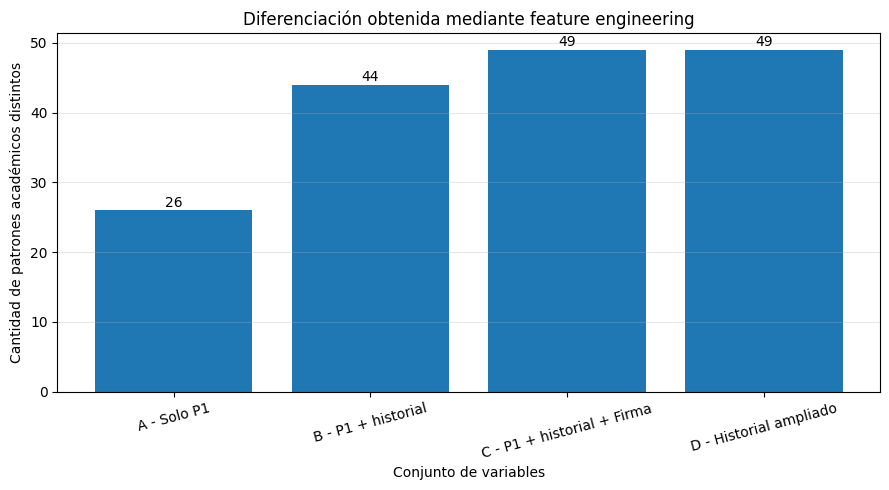

In [9]:
plt.figure(figsize=(9, 5))

barras = plt.bar(
    resumen_diferenciacion["Conjunto"],
    resumen_diferenciacion["Patrones_distintos"]
)

for barra, valor in zip(
    barras,
    resumen_diferenciacion["Patrones_distintos"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.5,
        str(valor),
        ha="center"
    )

plt.ylabel("Cantidad de patrones académicos distintos")
plt.xlabel("Conjunto de variables")
plt.title("Diferenciación obtenida mediante feature engineering")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 6. EDA — análisis exploratorio

En esta parte describo los **98 registros de cursada que mantuve**.

Quiero responder:

- cuántos datos tengo;
- si existen valores faltantes;
- cómo se distribuye el target;
- cómo cambia el primer parcial entre quienes aprobaron y quienes no;
- cómo se comportan las nuevas features construidas.



In [10]:
columnas_eda = [
    "Anho",
    "Semestre",
    "Plan_norm",
    "Primer.Par",
    "materias_cursadas_anterior",
    "materias_aprobadas_anterior",
    "tasa_aprobacion_anterior",
    "promedio_firma_anterior",
    "promedio_P1_anterior",
    "promedio_P2_anterior",
    "Nota.Final",
    "NotaFinal_num",
    "y"
]

print("Dimensiones del conjunto EDA:", senales[columnas_eda].shape)

print("\nTipos de variables:")
print(
    senales[columnas_eda].dtypes
)

print("\nValores faltantes:")
print(
    senales[columnas_eda]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nEstadísticas del Primer Parcial:")
display(
    senales.groupby("y")["Primer.Par"]
    .describe()
    .rename(index={
        0: "No aprobó",
        1: "Aprobó"
    })
    .round(2)
)

print("\nPromedios de features construidas por resultado:")
display(
    senales.groupby("y")[
        [
            "materias_cursadas_anterior",
            "materias_aprobadas_anterior",
            "tasa_aprobacion_anterior",
            "promedio_firma_anterior",
            "promedio_P1_anterior",
            "promedio_P2_anterior"
        ]
    ]
    .mean()
    .rename(index={
        0: "No aprobó",
        1: "Aprobó"
    })
    .round(3)
)

Dimensiones del conjunto EDA: (98, 13)

Tipos de variables:
Anho                                    int64
Semestre                                int64
Plan_norm                              object
Primer.Par                              int64
materias_cursadas_anterior              int64
materias_aprobadas_anterior             int64
tasa_aprobacion_anterior              float64
promedio_firma_anterior               float64
promedio_P1_anterior                  float64
promedio_P2_anterior                  float64
Nota.Final                     string[python]
NotaFinal_num                         float64
y                                       int64
dtype: object

Valores faltantes:
NotaFinal_num                  32
Nota.Final                     32
Plan_norm                       0
Semestre                        0
Anho                            0
materias_cursadas_anterior      0
Primer.Par                      0
materias_aprobadas_anterior     0
tasa_aprobacion_anterior        0
pr

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
No aprobó,34.000,19.470,18.940,0.000,0.000,23.000,38.000,50.000
Aprobó,64.000,58.340,23.140,0.000,47.250,56.500,75.750,100.000



Promedios de features construidas por resultado:


,materias_cursadas_anterior,materias_aprobadas_anterior,tasa_aprobacion_anterior,promedio_firma_anterior,promedio_P1_anterior,promedio_P2_anterior
y,,,,,,
No aprobó,4.353,2.059,0.467,37.030,19.924,20.626
Aprobó,4.906,4.156,0.842,53.775,35.093,32.556


## Gráfico 1 — Cantidad de aprobados y no aprobados

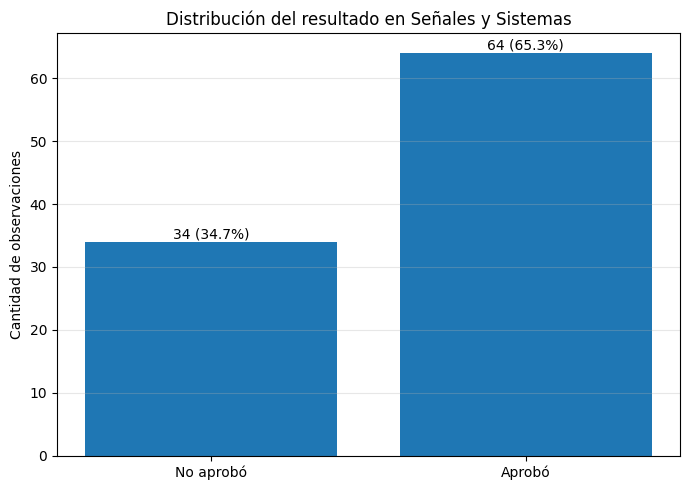

In [11]:
conteo_target = (
    senales["y"]
    .value_counts()
    .sort_index()
)

etiquetas = ["No aprobó", "Aprobó"]

plt.figure(figsize=(7, 5))
barras = plt.bar(
    etiquetas,
    conteo_target.values
)

total = conteo_target.sum()

for barra, valor in zip(barras, conteo_target.values):
    porcentaje = 100 * valor / total

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.5,
        f"{valor} ({porcentaje:.1f}%)",
        ha="center"
    )

plt.title("Distribución del resultado en Señales y Sistemas")
plt.ylabel("Cantidad de observaciones")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Gráfico 2 — Porcentaje de aprobación por año

Es análogo a los gráficos por período utilizados en el material del curso.

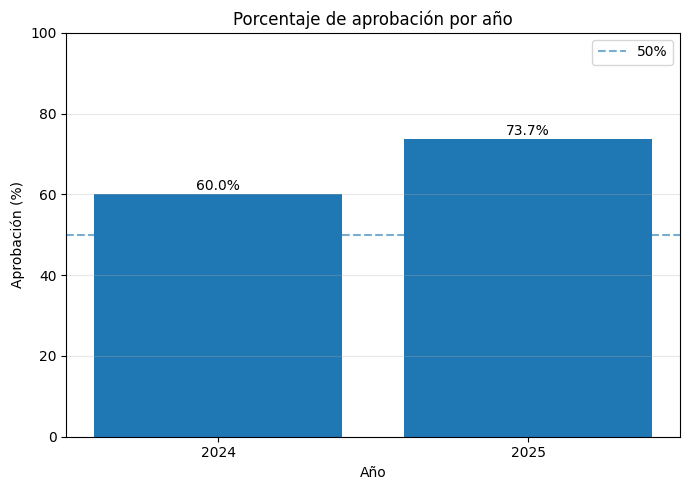

,Anho,count,sum,mean,porcentaje
0,2024,60,36,0.600,60.000
1,2025,38,28,0.737,73.684


In [12]:
aprobacion_anho = (
    senales.groupby("Anho")["y"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

aprobacion_anho["porcentaje"] = (
    aprobacion_anho["mean"] * 100
)

plt.figure(figsize=(7, 5))

barras = plt.bar(
    aprobacion_anho["Anho"].astype(str),
    aprobacion_anho["porcentaje"]
)

for barra, valor in zip(
    barras,
    aprobacion_anho["porcentaje"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 1,
        f"{valor:.1f}%",
        ha="center"
    )

plt.axhline(
    50,
    linestyle="--",
    alpha=0.6,
    label="50%"
)

plt.ylim(0, 100)
plt.xlabel("Año")
plt.ylabel("Aprobación (%)")
plt.title("Porcentaje de aprobación por año")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

display(aprobacion_anho.round(3))

## Gráfico 3 — Porcentaje de aprobación por malla

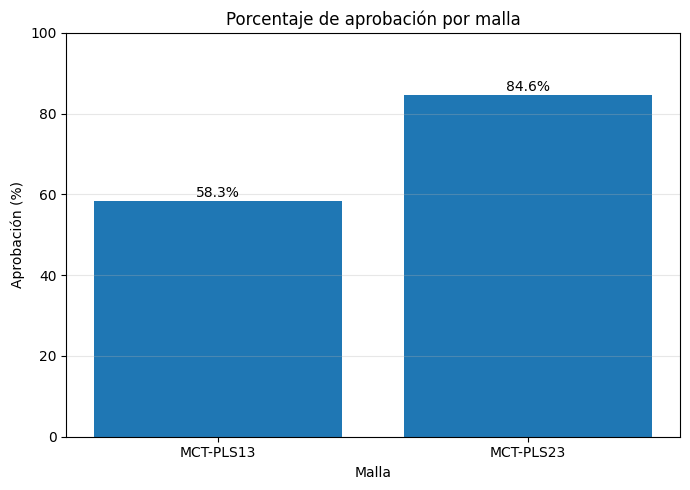

,Plan_norm,count,sum,mean,porcentaje
0,MCT-PLS13,72,42,0.583,58.333
1,MCT-PLS23,26,22,0.846,84.615


In [13]:
tabla_malla = (
    senales.groupby("Plan_norm")["y"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

tabla_malla["porcentaje"] = (
    tabla_malla["mean"] * 100
)

plt.figure(figsize=(7, 5))

barras = plt.bar(
    tabla_malla["Plan_norm"],
    tabla_malla["porcentaje"]
)

for barra, valor in zip(
    barras,
    tabla_malla["porcentaje"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 1,
        f"{valor:.1f}%",
        ha="center"
    )

plt.ylim(0, 100)
plt.ylabel("Aprobación (%)")
plt.xlabel("Malla")
plt.title("Porcentaje de aprobación por malla")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

display(tabla_malla.round(3))

## Gráfico 4 — Distribución de la nota del Primer Parcial

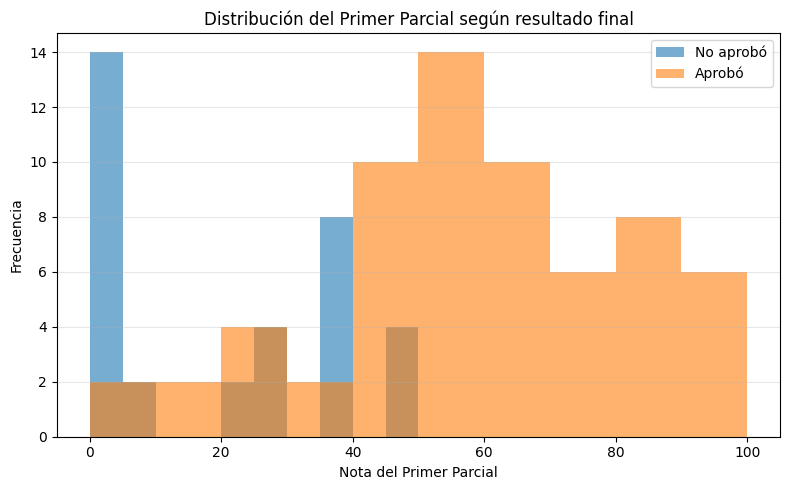

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(
    senales.loc[senales["y"] == 0, "Primer.Par"],
    bins=10,
    alpha=0.6,
    label="No aprobó"
)

plt.hist(
    senales.loc[senales["y"] == 1, "Primer.Par"],
    bins=10,
    alpha=0.6,
    label="Aprobó"
)

plt.xlabel("Nota del Primer Parcial")
plt.ylabel("Frecuencia")
plt.title("Distribución del Primer Parcial según resultado final")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Gráfico 5 — Boxplot del Primer Parcial

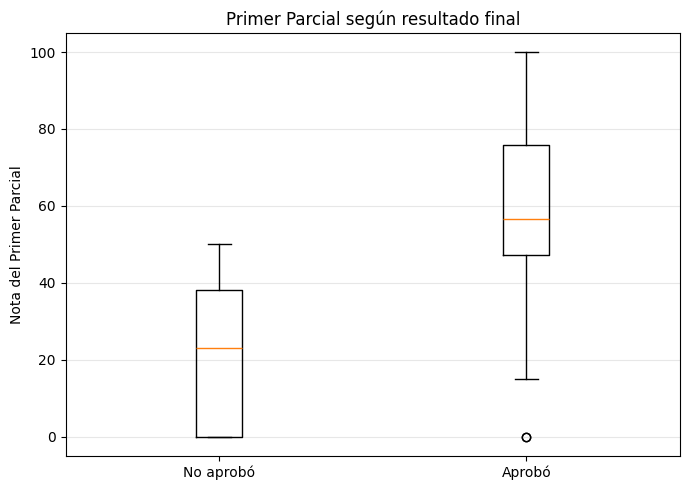

Media P1 - No aprobó: 19.47
Media P1 - Aprobó: 58.34


In [15]:
p1_no = (
    senales.loc[
        senales["y"] == 0,
        "Primer.Par"
    ]
    .dropna()
)

p1_si = (
    senales.loc[
        senales["y"] == 1,
        "Primer.Par"
    ]
    .dropna()
)

plt.figure(figsize=(7, 5))

plt.boxplot(
    [p1_no, p1_si],
    tick_labels=[
        "No aprobó",
        "Aprobó"
    ]
)

plt.ylabel("Nota del Primer Parcial")
plt.title("Primer Parcial según resultado final")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(
    "Media P1 - No aprobó:",
    round(p1_no.mean(), 2)
)

print(
    "Media P1 - Aprobó:",
    round(p1_si.mean(), 2)
)

# 7. Feature engineering del semestre anterior

En esta etapa se tienen construidas las variables históricas para los 98 registros.

Las principales son:

- `materias_cursadas_anterior`;
- `materias_aprobadas_anterior`;
- `tasa_aprobacion_anterior`;
- `promedio_firma_anterior`;
- `promedio_P1_anterior`;
- `promedio_P2_anterior`.



In [16]:
print("Promedios según resultado final:")

display(
    senales.groupby("y")[
        [
            "Primer.Par",
            "materias_cursadas_anterior",
            "materias_aprobadas_anterior",
            "tasa_aprobacion_anterior",
            "promedio_firma_anterior",
            "promedio_P1_anterior",
            "promedio_P2_anterior"
        ]
    ]
    .mean()
    .rename(index={
        0: "No aprobó",
        1: "Aprobó"
    })
    .round(3)
)

print("\nCantidad de patrones distintos según el feature engineering:")
display(
    resumen_diferenciacion
)

Promedios según resultado final:


,Primer.Par,materias_cursadas_anterior,materias_aprobadas_anterior,tasa_aprobacion_anterior,promedio_firma_anterior,promedio_P1_anterior,promedio_P2_anterior
y,,,,,,,
No aprobó,19.471,4.353,2.059,0.467,37.030,19.924,20.626
Aprobó,58.344,4.906,4.156,0.842,53.775,35.093,32.556



Cantidad de patrones distintos según el feature engineering:


,Conjunto,Features,Patrones_distintos,Max_repeticiones_mismo_patron,Patrones_repetidos
0,A - Solo P1,1,26,16,26
1,B - P1 + historial,4,44,4,44
2,C - P1 + historial + Firma,5,49,2,49
3,D - Historial ampliado,8,49,2,49


## Gráfico 6 — Tasa de aprobación del semestre anterior

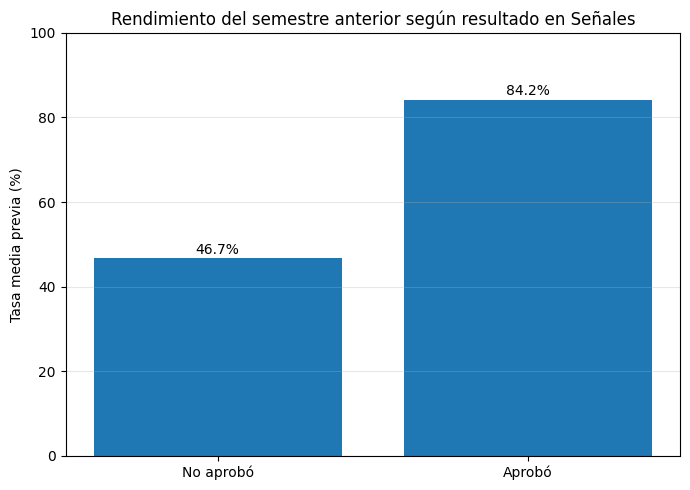

In [17]:
tasas = (
    senales.groupby("y")[
        "tasa_aprobacion_anterior"
    ]
    .mean()
    .sort_index()
    * 100
)

plt.figure(figsize=(7, 5))

barras = plt.bar(
    ["No aprobó", "Aprobó"],
    tasas.values
)

for barra, valor in zip(
    barras,
    tasas.values
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 1,
        f"{valor:.1f}%",
        ha="center"
    )

plt.ylim(0, 100)
plt.ylabel("Tasa media previa (%)")
plt.title(
    "Rendimiento del semestre anterior según resultado en Señales"
)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Gráfico — Promedio de Firma del semestre anterior

Aquí comparo el promedio de Firma previo entre quienes finalmente aprobaron y quienes no aprobaron Señales y Sistemas.



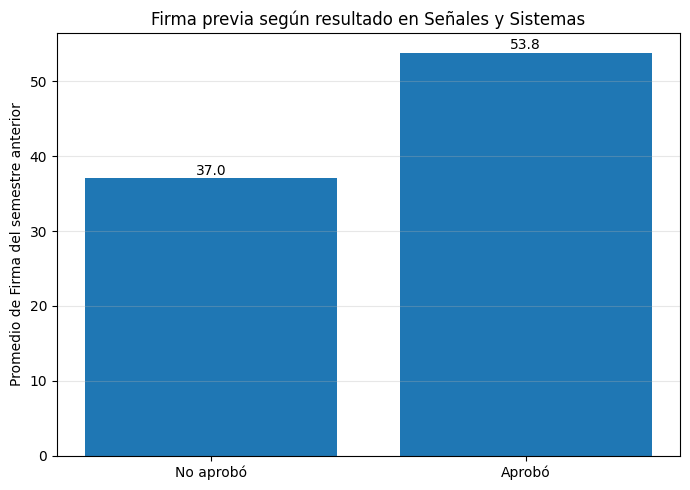

In [18]:
firma_por_resultado = (
    senales.groupby("y")[
        "promedio_firma_anterior"
    ]
    .mean()
    .sort_index()
)

plt.figure(figsize=(7, 5))

barras = plt.bar(
    ["No aprobó", "Aprobó"],
    firma_por_resultado.values
)

for barra, valor in zip(
    barras,
    firma_por_resultado.values
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.5,
        f"{valor:.1f}",
        ha="center"
    )

plt.ylabel("Promedio de Firma del semestre anterior")
plt.title("Firma previa según resultado en Señales y Sistemas")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Gráfico 7 — Primer Parcial vs rendimiento previo

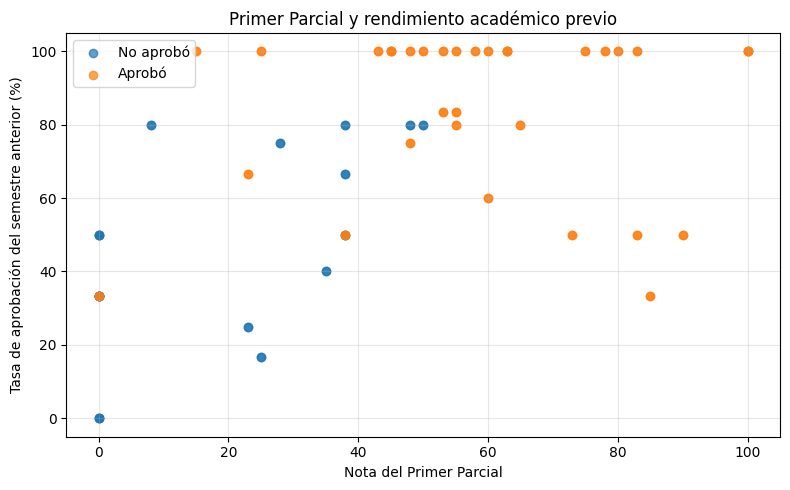

In [19]:
plt.figure(figsize=(8, 5))

for clase, etiqueta in [
    (0, "No aprobó"),
    (1, "Aprobó")
]:

    datos = senales[
        senales["y"] == clase
    ]

    plt.scatter(
        datos["Primer.Par"],
        datos["tasa_aprobacion_anterior"] * 100,
        alpha=0.7,
        label=etiqueta
    )

plt.xlabel("Nota del Primer Parcial")
plt.ylabel("Tasa de aprobación del semestre anterior (%)")
plt.title("Primer Parcial y rendimiento académico previo")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Prerrequisitos

- Malla vieja `MCT-PLS13`: Métodos Numéricos.
- Malla nueva `MCT-PLS23`: Métodos Numéricos + Estadística.

La nota se extrae desde `Nota.Final`.

Se estudian como parte del feature engineering, pero **no se incorporan al modelo principal** si la cobertura histórica es insuficiente, porque la base comienza en 2024-1.

In [20]:
df["periodo"] = (
    df["Anho"] * 2
    + df["Semestre"]
)

senales["periodo"] = (
    senales["Anho"] * 2
    + senales["Semestre"]
)

# Filtrar una sola vez las materias prerrequisito.
# Esto evita recorrer toda la base de 87 mil filas para cada alumno.
prerrequisitos_hist = df[
    df["Asignatura_norm"].isin([
        "METODOS NUMERICOS",
        "ESTADISTICA"
    ])
].copy()

prerrequisitos_hist = (
    prerrequisitos_hist
    .sort_values([
        "ALUMNO_ID",
        "periodo",
        "Convocatoria"
    ])
)


def ultima_nota_previa(
    alumno_id,
    periodo_actual,
    asignatura_norm
):

    historia = prerrequisitos_hist[
        (prerrequisitos_hist["ALUMNO_ID"] == alumno_id)
        &
        (prerrequisitos_hist["periodo"] < periodo_actual)
        &
        (
            prerrequisitos_hist["Asignatura_norm"]
            == asignatura_norm
        )
    ]

    if historia.empty:
        return np.nan

    notas_validas = (
        historia["NotaFinal_num"]
        .dropna()
    )

    if notas_validas.empty:
        return np.nan

    return float(
        notas_validas.iloc[-1]
    )


notas_metodos = []
notas_estadistica = []

for _, fila in senales.iterrows():

    uid = fila["ALUMNO_ID"]
    periodo_actual = fila["periodo"]

    nota_mn = ultima_nota_previa(
        uid,
        periodo_actual,
        "METODOS NUMERICOS"
    )

    if fila["malla_nueva"] == 1:

        nota_est = ultima_nota_previa(
            uid,
            periodo_actual,
            "ESTADISTICA"
        )

    else:

        nota_est = np.nan

    notas_metodos.append(nota_mn)
    notas_estadistica.append(nota_est)


senales["nota_metodos_numericos"] = (
    notas_metodos
)

senales["nota_estadistica"] = (
    notas_estadistica
)

senales["promedio_prerrequisitos"] = np.where(
    senales["malla_nueva"] == 0,
    senales["nota_metodos_numericos"],
    (
        senales["nota_metodos_numericos"]
        + senales["nota_estadistica"]
    ) / 2
)

cobertura_mn = (
    100
    * senales[
        "nota_metodos_numericos"
    ]
    .notna()
    .mean()
)

mask_nueva = (
    senales["malla_nueva"] == 1
)

cobertura_est = (
    100
    * senales.loc[
        mask_nueva,
        "nota_estadistica"
    ]
    .notna()
    .mean()
)

cobertura_completa = (
    100
    * senales[
        "promedio_prerrequisitos"
    ]
    .notna()
    .mean()
)

print(
    f"Cobertura Métodos Numéricos: "
    f"{cobertura_mn:.1f}%"
)

print(
    f"Cobertura Estadística en malla nueva: "
    f"{cobertura_est:.1f}%"
)

print(
    f"Cobertura completa de prerrequisitos: "
    f"{cobertura_completa:.1f}%"
)

Cobertura Métodos Numéricos: 71.4%
Cobertura Estadística en malla nueva: 46.2%
Cobertura completa de prerrequisitos: 59.2%


## Gráfico 8 — Cobertura de prerrequisitos

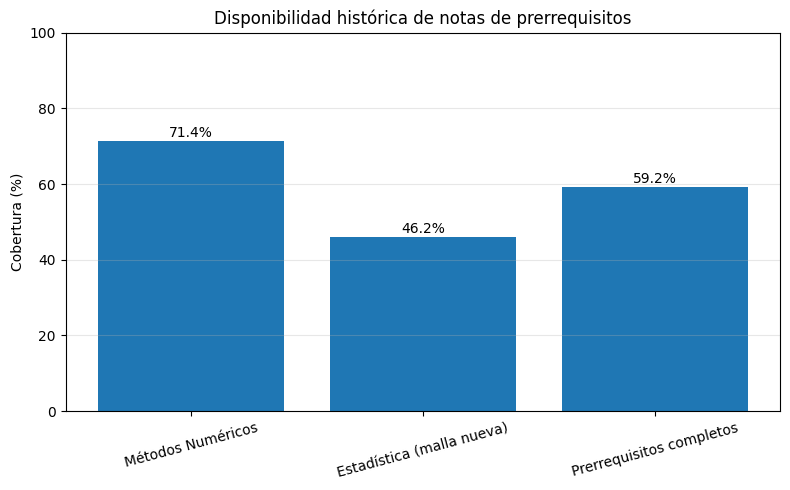

In [21]:
nueva_total = int(mask_nueva.sum())

cobertura_tabla = pd.DataFrame({
    "Variable": [
        "Métodos Numéricos",
        "Estadística (malla nueva)",
        "Prerrequisitos completos"
    ],
    "Cobertura": [
        cobertura_mn,
        cobertura_est,
        cobertura_completa
    ]
})

plt.figure(figsize=(8, 5))

barras = plt.bar(
    cobertura_tabla["Variable"],
    cobertura_tabla["Cobertura"]
)

for barra, valor in zip(
    barras,
    cobertura_tabla["Cobertura"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 1,
        f"{valor:.1f}%",
        ha="center"
    )

plt.ylim(0, 100)
plt.ylabel("Cobertura (%)")
plt.title("Disponibilidad histórica de notas de prerrequisitos")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Variables finales del modelo

No se asumira que **más variables siempre significa mejor modelo**.

Por eso se compara cuatro niveles:

### A — Baseline
- `Primer.Par`

### B — Historial básico
- `Primer.Par`
- materias cursadas
- materias aprobadas
- tasa de aprobación

### C — Historial + Firma
Agrego:
- `promedio_firma_anterior`

### D — Historial ampliado
Agrego además:
- promedio de P1 anterior;
- promedio de P2 anterior;
- indicador de malla.

El conjunto principal para la primera prueba será **C — P1 + historial + Firma**, porque incorpora directamente la recomendación del profesor. Después comparo todos los conjuntos con validación cruzada.

`Nota.Final`, recuperatorios, segundo parcial de Señales y Firma de Señales **no son entradas**, porque serían información posterior al momento de predicción.

In [22]:
# ============================================================
# CONJUNTOS DE FEATURES
# ============================================================

features_baseline = [
    "Primer.Par"
]

features_historial = [
    "Primer.Par",
    "materias_cursadas_anterior",
    "materias_aprobadas_anterior",
    "tasa_aprobacion_anterior"
]

features_firma = [
    "Primer.Par",
    "materias_cursadas_anterior",
    "materias_aprobadas_anterior",
    "tasa_aprobacion_anterior",
    "promedio_firma_anterior"
]

features_ampliadas = [
    "Primer.Par",
    "materias_cursadas_anterior",
    "materias_aprobadas_anterior",
    "tasa_aprobacion_anterior",
    "promedio_firma_anterior",
    "promedio_P1_anterior",
    "promedio_P2_anterior",
    "malla_nueva"
]

experimentos_features = {
    "A_Solo_P1": features_baseline,
    "B_P1_historial": features_historial,
    "C_P1_historial_Firma": features_firma,
    "D_Historial_ampliado": features_ampliadas
}


# Primera evaluación: utilizo el conjunto con Firma
features_final = features_firma

X = senales[
    features_final
].copy()

y = senales[
    "y"
].copy()

groups = senales[
    "grupo_evaluacion"
].copy()

print("Features de la primera evaluación:")
print(features_final)

print("\nDimensiones de X:")
print(X.shape)

display(
    X.describe().round(3)
)

Features de la primera evaluación:
['Primer.Par', 'materias_cursadas_anterior', 'materias_aprobadas_anterior', 'tasa_aprobacion_anterior', 'promedio_firma_anterior']

Dimensiones de X:
(98, 5)


,Primer.Par,materias_cursadas_anterior,materias_aprobadas_anterior,tasa_aprobacion_anterior,promedio_firma_anterior
count,98.000,98.000,98.000,98.000,98.000
mean,44.857,4.714,3.429,0.712,47.966
std,28.559,1.377,1.782,0.299,15.027
min,0.000,2.000,0.000,0.000,7.600
25%,25.000,4.000,2.000,0.500,36.000
50%,48.000,5.000,4.000,0.800,49.600
75%,63.000,6.000,5.000,1.000,57.000
max,100.000,8.000,7.000,1.000,79.667


## Gráfico 9 — Matriz de correlación de las variables del modelo

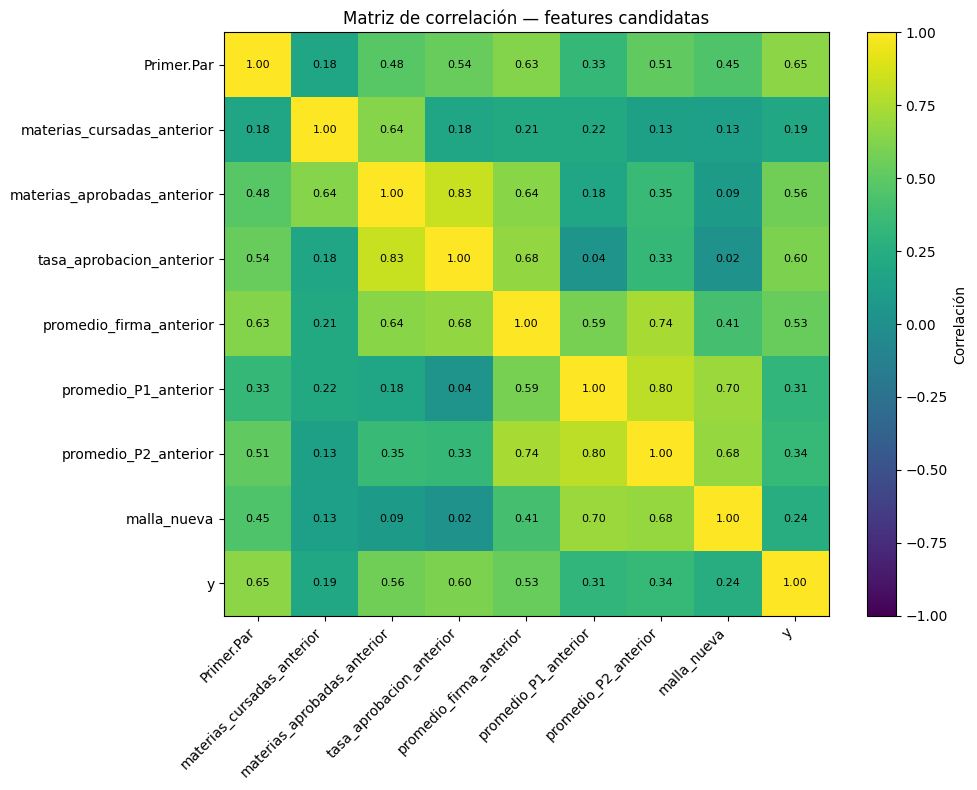

In [23]:
corr_df = (
    senales[
        features_ampliadas + ["y"]
    ]
    .corr()
)

plt.figure(figsize=(10, 8))

imagen = plt.imshow(
    corr_df.values,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

plt.colorbar(
    imagen,
    label="Correlación"
)

plt.xticks(
    range(len(corr_df.columns)),
    corr_df.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_df.index)),
    corr_df.index
)

for i in range(len(corr_df.index)):
    for j in range(len(corr_df.columns)):
        plt.text(
            j,
            i,
            f"{corr_df.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Matriz de correlación — features candidatas")
plt.tight_layout()
plt.show()

# 10. Separación entrenamiento/prueba por grupos

Se mantienen los 98 registros, pero **no se permito que el mismo estudiante o dos registros con entradas idénticas se separen entre entrenamiento y prueba**.

Para eso se utilizo `grupo_evaluacion`.


In [24]:
splitter = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    splitter.split(
        X,
        y,
        groups=groups
    )
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Entrenamiento:", len(X_train))
print("Prueba:", len(X_test))

print("\nClases en entrenamiento:")
print(y_train.value_counts())

print("\nClases en prueba:")
print(y_test.value_counts())

Entrenamiento: 68
Prueba: 30

Clases en entrenamiento:
y
1    38
0    30
Name: count, dtype: int64

Clases en prueba:
y
1    26
0     4
Name: count, dtype: int64


# 11. Entrenamiento de tres modelos

In [25]:
modelos = {

    "Regresión Logística": Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "modelo",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]),

    "Árbol de Decisión": Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "modelo",
            DecisionTreeClassifier(
                max_depth=3,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]),

    "Random Forest": Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=150,
                max_depth=4,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=1
            )
        )
    ])
}

# 12. Evaluación sobre el primer conjunto de prueba

In [26]:
resultados = []
predicciones = {}
probabilidades = {}

for nombre, modelo in modelos.items():

    modelo.fit(
        X_train,
        y_train
    )

    y_pred = modelo.predict(
        X_test
    )

    y_prob = modelo.predict_proba(
        X_test
    )[:, 1]

    predicciones[nombre] = y_pred
    probabilidades[nombre] = y_prob

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_test,
            y_prob
        )
    })

resultados_df = (
    pd.DataFrame(resultados)
    .sort_values(
        ["F1", "ROC_AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    resultados_df.round(3)
)

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
0,Regresión Logística,0.933,1.000,0.923,0.960,0.962
1,Random Forest,0.867,1.000,0.846,0.917,0.962
2,Árbol de Decisión,0.733,0.909,0.769,0.833,0.846


In [ ]:
print(features_final)

## Gráfico 10 — Comparación de métricas de los modelos

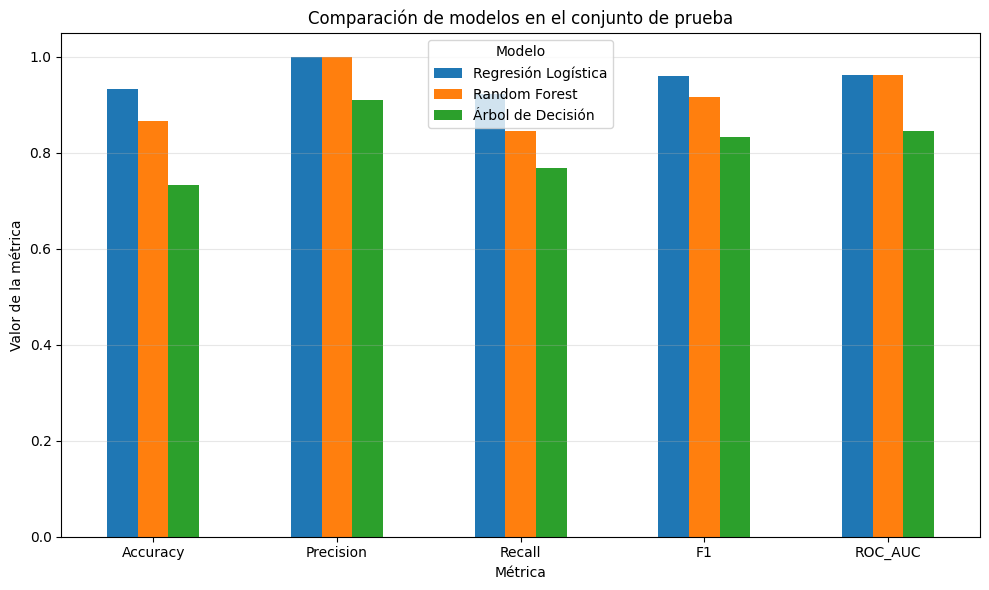

In [27]:
metricas_largo = (
    resultados_df
    .set_index("Modelo")[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC"
        ]
    ]
)

ax = metricas_largo.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylim(0, 1.05)
plt.ylabel("Valor de la métrica")
plt.xlabel("Métrica")
plt.title("Comparación de modelos en el conjunto de prueba")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Modelo")
plt.tight_layout()
plt.show()

## Gráfico 11 — Curvas ROC

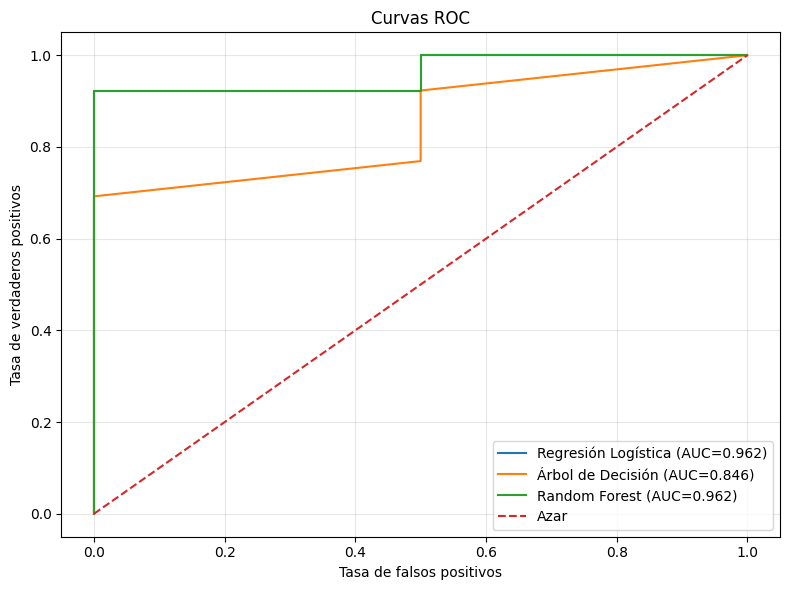

In [28]:
plt.figure(figsize=(8, 6))

for nombre in modelos.keys():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilidades[nombre]
    )

    auc = roc_auc_score(
        y_test,
        probabilidades[nombre]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{nombre} (AUC={auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Azar"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Gráfico 12 — Matriz de confusión del mejor modelo del primer test

Se selecciona aquí por `F1`.

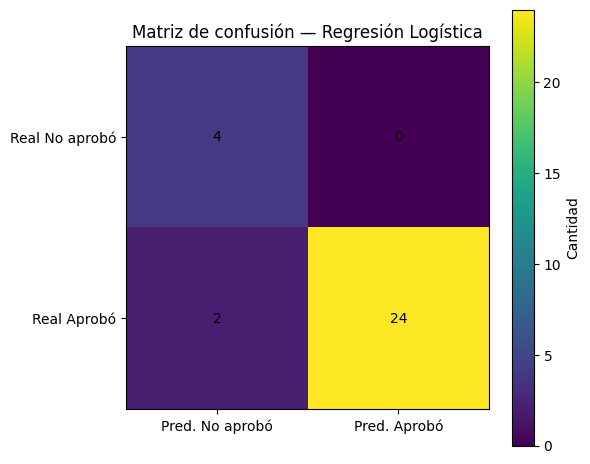

              precision    recall  f1-score   support

   No aprobó       0.67      1.00      0.80         4
      Aprobó       1.00      0.92      0.96        26

    accuracy                           0.93        30
   macro avg       0.83      0.96      0.88        30
weighted avg       0.96      0.93      0.94        30



In [29]:
mejor_modelo_test = (
    resultados_df.iloc[0]["Modelo"]
)

mejor_pred = (
    predicciones[
        mejor_modelo_test
    ]
)

matriz = confusion_matrix(
    y_test,
    mejor_pred
)

plt.figure(figsize=(6, 5))

imagen = plt.imshow(
    matriz
)

plt.colorbar(
    imagen,
    label="Cantidad"
)

plt.xticks(
    [0, 1],
    [
        "Pred. No aprobó",
        "Pred. Aprobó"
    ]
)

plt.yticks(
    [0, 1],
    [
        "Real No aprobó",
        "Real Aprobó"
    ]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            str(matriz[i, j]),
            ha="center",
            va="center"
        )

plt.title(
    f"Matriz de confusión — {mejor_modelo_test}"
)

plt.tight_layout()
plt.show()

print(
    classification_report(
        y_test,
        mejor_pred,
        target_names=[
            "No aprobó",
            "Aprobó"
        ],
        zero_division=0
    )
)

# 13. Comparación robusta de feature engineering


Se comparo solamente algoritmos. También se compara **qué información le doy al modelo**:

- solo P1;
- P1 + historial;
- P1 + historial + promedio de Firma;
- historial ampliado.



In [30]:
comparaciones = []

for fold, (tr, te) in enumerate(
    splitter.split(
        np.zeros(len(senales)),
        senales["y"],
        groups=senales["grupo_evaluacion"]
    ),
    start=1
):

    for experimento, columnas in experimentos_features.items():

        for nombre, modelo in modelos.items():

            # Cada fold comienza con un modelo limpio
            modelo_fold = clone(modelo)

            modelo_fold.fit(
                senales.iloc[tr][columnas],
                senales.iloc[tr]["y"]
            )

            pred = modelo_fold.predict(
                senales.iloc[te][columnas]
            )

            prob = modelo_fold.predict_proba(
                senales.iloc[te][columnas]
            )[:, 1]

            comparaciones.append({
                "Fold": fold,
                "Experimento": experimento,
                "Modelo": nombre,
                "Accuracy": accuracy_score(
                    senales.iloc[te]["y"],
                    pred
                ),
                "Precision": precision_score(
                    senales.iloc[te]["y"],
                    pred,
                    zero_division=0
                ),
                "Recall": recall_score(
                    senales.iloc[te]["y"],
                    pred,
                    zero_division=0
                ),
                "F1": f1_score(
                    senales.iloc[te]["y"],
                    pred,
                    zero_division=0
                ),
                "ROC_AUC": roc_auc_score(
                    senales.iloc[te]["y"],
                    prob
                )
            })

comparacion_df = pd.DataFrame(
    comparaciones
)

promedios = (
    comparacion_df
    .groupby([
        "Experimento",
        "Modelo"
    ])[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC"
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(
        ["F1", "ROC_AUC"],
        ascending=False
    )
)

display(
    promedios.round(3)
)

print(
    "\nImportante: si el conjunto con más features no queda primero, "
    "eso no significa que el feature engineering esté mal. "
    "Puede significar que algunas variables agregan ruido o redundancia."
)

,Experimento,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
6,C_P1_historial_Firma,Random Forest,0.875,0.933,0.878,0.902,0.905
7,C_P1_historial_Firma,Regresión Logística,0.878,0.900,0.904,0.901,0.942
4,B_P1_historial,Regresión Logística,0.878,0.900,0.904,0.901,0.935
10,D_Historial_ampliado,Regresión Logística,0.854,0.909,0.878,0.888,0.942
9,D_Historial_ampliado,Random Forest,0.838,0.856,0.915,0.877,0.931
5,B_P1_historial,Árbol de Decisión,0.834,0.906,0.845,0.870,0.859
3,B_P1_historial,Random Forest,0.835,0.909,0.845,0.869,0.941
1,A_Solo_P1,Regresión Logística,0.835,0.909,0.845,0.869,0.927
8,C_P1_historial_Firma,Árbol de Decisión,0.812,0.903,0.819,0.855,0.837
11,D_Historial_ampliado,Árbol de Decisión,0.812,0.903,0.819,0.855,0.824



Importante: si el conjunto con más features no queda primero, eso no significa que el feature engineering esté mal. Puede significar que algunas variables agregan ruido o redundancia.


## Gráfico 13 — Efecto del feature engineering sobre F1

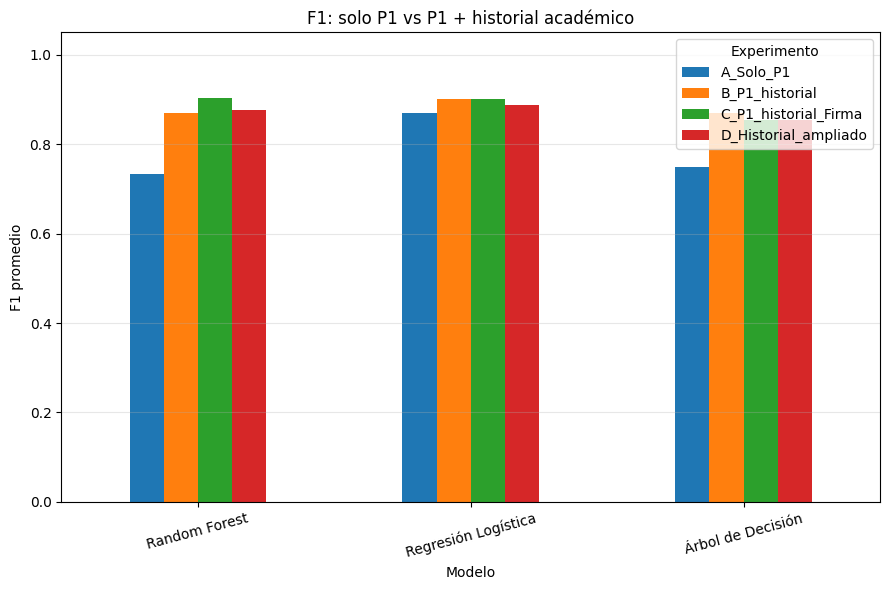

In [31]:
tabla_f1 = (
    promedios.pivot(
        index="Modelo",
        columns="Experimento",
        values="F1"
    )
)

ax = tabla_f1.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.ylim(0, 1.05)
plt.ylabel("F1 promedio")
plt.xlabel("Modelo")
plt.title("F1: solo P1 vs P1 + historial académico")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Experimento")
plt.tight_layout()
plt.show()

# 14. Importancia de variables del Random Forest

Para interpretar el efecto del nuevo feature engineering, entreno un Random Forest con el conjunto que incluye el **promedio de Firma**.

La importancia indica cuánto utiliza el modelo cada variable para separar casos. No significa causalidad.


,Importancia
Primer.Par,0.339
promedio_firma_anterior,0.222
tasa_aprobacion_anterior,0.217
materias_aprobadas_anterior,0.171
materias_cursadas_anterior,0.050


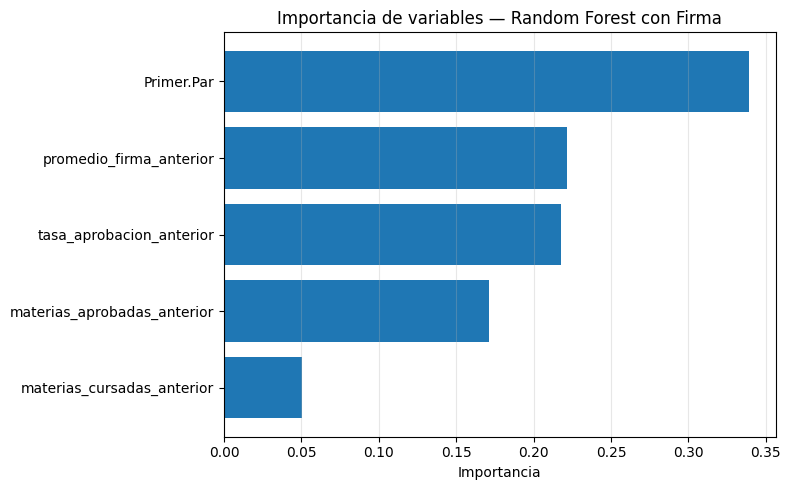

In [32]:
# Random Forest con el conjunto que incorpora Firma
X_rf = senales[
    features_firma
].copy()

train_idx_rf, test_idx_rf = next(
    splitter.split(
        X_rf,
        y,
        groups=groups
    )
)

rf_interpretable = clone(
    modelos["Random Forest"]
)

rf_interpretable.fit(
    X_rf.iloc[train_idx_rf],
    y.iloc[train_idx_rf]
)

importancias = pd.Series(
    rf_interpretable
    .named_steps["modelo"]
    .feature_importances_,
    index=features_firma
).sort_values(
    ascending=False
)

display(
    importancias
    .rename("Importancia")
    .to_frame()
    .round(3)
)

plt.figure(figsize=(8, 5))

plt.barh(
    importancias.index[::-1],
    importancias.values[::-1]
)

plt.xlabel("Importancia")
plt.title(
    "Importancia de variables — Random Forest con Firma"
)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# 15. Selección del modelo y conclusiones

Para la conclusión final se elegira el modelo por una única partición.

Se ordena todas las combinaciones **experimento + modelo** usando principalmente el `F1` promedio de los tres folds y utilizo `ROC_AUC` como criterio complementario.

Esto también permite decir si el promedio de Firma ayudó a diferenciar mejor las entradas aunque no necesariamente haya aumentado la métrica final.

In [33]:
ranking_final = (
    promedios
    .sort_values(
        ["F1", "ROC_AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    ranking_final.round(3)
)

mejor_experimento = ranking_final.iloc[0]["Experimento"]
mejor_modelo_cv = ranking_final.iloc[0]["Modelo"]
mejor_f1 = ranking_final.iloc[0]["F1"]
mejor_auc = ranking_final.iloc[0]["ROC_AUC"]

print(
    "Mejor combinación según F1 promedio:"
)

print(
    f"Experimento: {mejor_experimento}"
)

print(
    f"Modelo: {mejor_modelo_cv}"
)

print(
    f"F1 promedio: {mejor_f1:.3f}"
)

print(
    f"ROC-AUC promedio: {mejor_auc:.3f}"
)


# Comparar específicamente la capacidad de diferenciación
print("\nDiferenciación de entradas:")

for nombre, columnas in experimentos_features.items():

    patrones = (
        senales[columnas]
        .drop_duplicates()
        .shape[0]
    )

    print(
        f"{nombre}: {patrones} patrones distintos "
        f"sobre {len(senales)} registros"
    )

,Experimento,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
0,C_P1_historial_Firma,Random Forest,0.875,0.933,0.878,0.902,0.905
1,C_P1_historial_Firma,Regresión Logística,0.878,0.900,0.904,0.901,0.942
2,B_P1_historial,Regresión Logística,0.878,0.900,0.904,0.901,0.935
3,D_Historial_ampliado,Regresión Logística,0.854,0.909,0.878,0.888,0.942
4,D_Historial_ampliado,Random Forest,0.838,0.856,0.915,0.877,0.931
5,B_P1_historial,Árbol de Decisión,0.834,0.906,0.845,0.870,0.859
6,B_P1_historial,Random Forest,0.835,0.909,0.845,0.869,0.941
7,A_Solo_P1,Regresión Logística,0.835,0.909,0.845,0.869,0.927
8,C_P1_historial_Firma,Árbol de Decisión,0.812,0.903,0.819,0.855,0.837
9,D_Historial_ampliado,Árbol de Decisión,0.812,0.903,0.819,0.855,0.824


Mejor combinación según F1 promedio:
Experimento: C_P1_historial_Firma
Modelo: Random Forest
F1 promedio: 0.902
ROC-AUC promedio: 0.905

Diferenciación de entradas:
A_Solo_P1: 26 patrones distintos sobre 98 registros
B_P1_historial: 44 patrones distintos sobre 98 registros
C_P1_historial_Firma: 49 patrones distintos sobre 98 registros
D_Historial_ampliado: 49 patrones distintos sobre 98 registros
